# FGSM: Fast Gradient Sign Method on Raw Audio Waveforms

The most direct cross-domain translation in this whole project family. In `adversarial_attacks_nlp`,
FGSM had to be reinvented as HotFlip because text is discrete. Here it does not: a waveform is
already a vector of continuous, real-valued amplitudes, exactly the kind of input FGSM was designed
for, so the derivation and the code are essentially identical to `attacks/whitebox/01_FGSM.ipynb` in the vision
repo, with pixels swapped for audio samples.

$$x_{adv} = x + \varepsilon \cdot \text{sign}(\nabla_x J(\theta, x, y))$$

The perturbation is bounded in $L_\infty$ amplitude, same convention as the vision repo; whether a
given $\varepsilon$ is actually inaudible is a separate, genuinely audio-specific question (loudness
and psychoacoustic masking, not just a small number), touched on in the evaluation below.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import soundfile as sf
import matplotlib.pyplot as plt

torch.manual_seed(0)

def _load_wav(path, frame_offset=0, num_frames=-1, normalize=True, channels_first=True, format=None, buffer_size=4096, backend=None):
    """Replaces torchaudio's TorchCodec-based loader (needs a separately installed FFmpeg, not
    available here) with soundfile, which reads WAV directly with no extra system dependencies."""
    data, sample_rate = sf.read(path, dtype='float32')
    waveform = torch.from_numpy(data)
    if waveform.dim() == 1:
        waveform = waveform.unsqueeze(1)
    if channels_first:
        waveform = waveform.transpose(0, 1)
    return waveform, sample_rate

torchaudio.load = _load_wav

### Setup: Load the Trained Keyword Spotter
Same `KeywordCNN` architecture and log-mel front end trained in `models/01_train_keyword_spotter.ipynb`,
loading its saved weights rather than retraining.

In [2]:
LABELS = ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go']
SAMPLE_RATE = 16000

mel_spectrogram = torchaudio.transforms.MelSpectrogram(sample_rate=SAMPLE_RATE, n_mels=64, n_fft=400, hop_length=160)
to_db = torchaudio.transforms.AmplitudeToDB()

def waveform_to_spectrogram(waveform):
    return to_db(mel_spectrogram(waveform))

class KeywordCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, spectrogram):
        x = self.pool(F.relu(self.bn1(self.conv1(spectrogram))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.global_pool(x).flatten(1)
        return self.fc(x)

model = KeywordCNN(num_classes=len(LABELS))
model.load_state_dict(torch.load('../models/keyword_spotter.pth', map_location='cpu'))
model.eval()
print("Loaded keyword_spotter.pth")

Loaded keyword_spotter.pth


### Setup: Test Clips
A handful of real test clips from Speech Commands, one per class, held out from training. `torchaudio`
re-downloads only the file index on a repeat run (the archive is cached from the training notebook).

In [3]:
import os

LABEL_TO_IDX = {label: i for i, label in enumerate(LABELS)}

os.makedirs('../models/speech_commands_data', exist_ok=True)  # SPEECHCOMMANDS(download=True) expects this to already exist
test_data = torchaudio.datasets.SPEECHCOMMANDS(root='../models/speech_commands_data', download=True, subset='testing')

def pad_or_trim(waveform):
    if waveform.shape[1] < SAMPLE_RATE:
        return F.pad(waveform, (0, SAMPLE_RATE - waveform.shape[1]))
    return waveform[:, :SAMPLE_RATE]

sample_clips = {}
for i in range(len(test_data)):
    waveform, sr, label, *_ = test_data[i]
    if label in LABEL_TO_IDX and label not in sample_clips:
        sample_clips[label] = pad_or_trim(waveform)
    if len(sample_clips) == len(LABELS):
        break

print(f"Collected {len(sample_clips)} sample clips, one per class")

Collected 10 sample clips, one per class


### The Attack
Identical structure to `attacks/whitebox/01_FGSM.ipynb` in the vision repo: a `GradientTape`-style backward
pass (here, plain PyTorch autograd) through the model, then a single signed step. The perturbation
is clipped to $[-1, 1]$, the valid range for a normalized waveform, the audio equivalent of clipping
pixel values to $[0, 255]$.

In [4]:
def fgsm_attack(waveform, true_label_idx, epsilon):
    waveform = waveform.clone().requires_grad_(True)
    logits = model(waveform_to_spectrogram(waveform.unsqueeze(0)))
    loss = F.cross_entropy(logits, torch.tensor([true_label_idx]))
    loss.backward()
    adv_waveform = waveform + epsilon * waveform.grad.sign()
    return torch.clamp(adv_waveform, -1.0, 1.0).detach()

def predict(waveform):
    with torch.no_grad():
        logits = model(waveform_to_spectrogram(waveform.unsqueeze(0)))
        probs = F.softmax(logits, dim=-1)[0]
        label_idx = int(torch.argmax(probs))
    return LABELS[label_idx], float(probs[label_idx]), label_idx

### Evaluation: Attack Success Rate vs. $\varepsilon$
Every sample clip, attacked at each $\varepsilon$, only counting clips the model already classifies
correctly (the same "robust accuracy" convention used throughout the vision and NLP repos), plus
the waveform Signal-to-Noise Ratio at each budget, since "how loud is the perturbation relative to
the speech" is the audio-specific stand-in for the vision repo's L2 pixel distortion.

In [5]:
EPSILONS = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]

def snr_db(clean, adv):
    noise_power = float(torch.sum((adv - clean) ** 2))
    signal_power = float(torch.sum(clean ** 2))
    if noise_power == 0:
        return float('inf')
    return 10 * torch.log10(torch.tensor(signal_power / noise_power)).item()

results = []
for label, waveform in sample_clips.items():
    true_idx = LABEL_TO_IDX[label]
    orig_label, orig_prob, orig_idx = predict(waveform)
    if orig_idx != true_idx:
        continue  # only attack clips the model already gets right

    for epsilon in EPSILONS:
        adv_waveform = fgsm_attack(waveform, true_idx, epsilon)
        adv_label, adv_prob, adv_idx = predict(adv_waveform)
        results.append({
            'Label': label, 'Epsilon': epsilon,
            'Success': adv_idx != true_idx, 'SNR_dB': snr_db(waveform, adv_waveform),
        })

import pandas as pd
results_df = pd.DataFrame(results)
results_df.to_csv('fgsm_audio_results.csv', index=False)
print(results_df.groupby('Epsilon')[['Success', 'SNR_dB']].mean())

         Success     SNR_dB
Epsilon                    
0.001      0.500  36.271208
0.005      0.625  22.291810
0.010      0.625  16.271210
0.020      0.625  10.250610
0.050      0.875   2.291808
0.100      1.000  -3.728792


### Plot: ASR and SNR vs. $\varepsilon$
Two axes on the same figure: Attack Success Rate should climb with $\varepsilon$, while SNR (higher
is quieter/more imperceptible) should fall, the fundamental attack-strength/perceptibility tradeoff
that every attack in this repo family faces in its own domain's units.

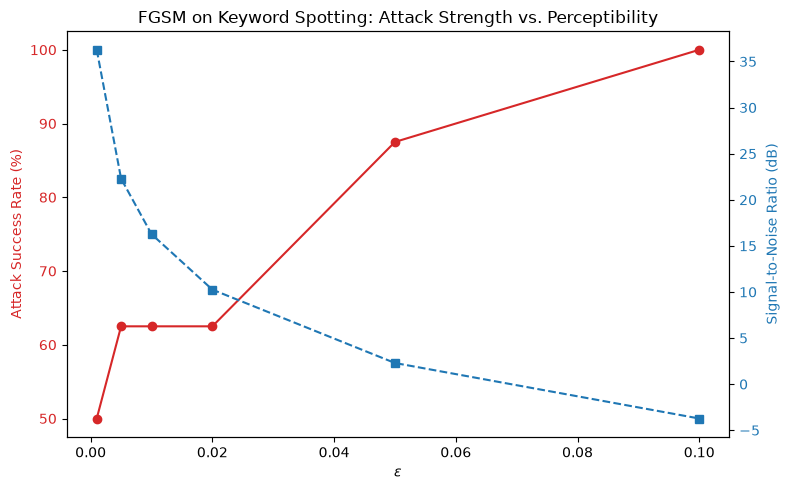

In [6]:
summary = results_df.groupby('Epsilon')[['Success', 'SNR_dB']].mean()

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(summary.index, summary['Success'] * 100, 'o-', color='tab:red', label='Attack Success Rate')
ax1.set_xlabel('$\\varepsilon$')
ax1.set_ylabel('Attack Success Rate (%)', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.plot(summary.index, summary['SNR_dB'], 's--', color='tab:blue', label='SNR (dB)')
ax2.set_ylabel('Signal-to-Noise Ratio (dB)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('FGSM on Keyword Spotting: Attack Strength vs. Perceptibility')
fig.tight_layout()
plt.show()